In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "908803302"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2)
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731840,0.41996,0.645490,0.60866,0.64906,0.61320,0.66505,0.62855,0.61867,0.56285
1,pythia-70M,8-bit,122.126910,0.41390,0.645250,0.60859,0.64803,0.61204,0.66492,0.62869,0.61855,0.56315
2,pythia-70M,4-bit,113.771070,0.39210,0.633570,0.60442,0.63208,0.60402,0.65657,0.62541,0.58659,0.54286
3,pythia-160M,Original,649.341190,0.42493,0.657010,0.61645,0.65590,0.61574,0.67443,0.63549,0.63949,0.58167
4,pythia-160M,8-bit,240.116640,0.42310,0.656575,0.61566,0.65523,0.61455,0.67410,0.63498,0.63815,0.58095
5,pythia-160M,4-bit,202.650480,0.40604,0.644996,0.61117,0.64187,0.60902,0.66678,0.63265,0.59686,0.55090
6,pythia-410M,Original,1621.430000,0.43509,0.674133,0.62689,0.67518,0.62664,0.68873,0.64419,0.67112,0.61244
7,pythia-410M,8-bit,509.700000,0.43612,0.673955,0.62687,0.67496,0.62672,0.68860,0.64400,0.67126,0.61226
8,pythia-410M,4-bit,376.750000,0.42411,0.656712,0.61908,0.65961,0.61924,0.67734,0.63884,0.60386,0.55770
9,pythia-1B,Original,4047.192000,0.44180,0.689923,0.63865,0.69074,0.63931,0.70291,0.65535,0.68342,0.63675


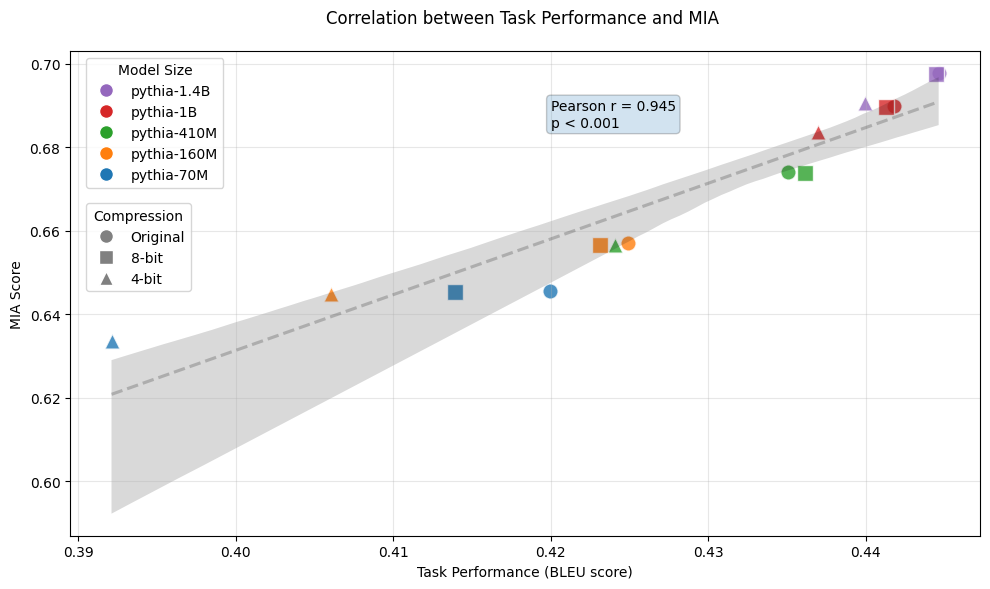

In [2]:
taskPerformance = "BLEU"
MIA_score = "ROC_AUC"
model_order = ['pythia-1.4B', 'pythia-1B','pythia-410M','pythia-160M', 'pythia-70M']

compression_order = ['Original', '8-bit', '4-bit']
markers = {'Original': 'o', '8-bit': 's', '4-bit': '^'}
colors = {'pythia-70M': '#1f77b4', 'pythia-160M': '#ff7f0e', 
          'pythia-410M': '#2ca02c', 'pythia-1B': '#d62728', 
          'pythia-1.4B': '#9467bd'}

# Create the optimized visualization
plt.figure(figsize=(10, 6))

# Plot each point with model-specific color and compression-specific marker
for model in model_order:
    for compression in compression_order:
        subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
        if not subset.empty:
            plt.scatter(subset[taskPerformance], subset[MIA_score],
                       c=colors[model],
                       marker=markers[compression],
                       s=120,
                       alpha=0.8,
                       edgecolors='w',
                       linewidths=1)

# Create custom legends
from matplotlib.lines import Line2D

# Model legend (color-coded)
model_legend_elements = [Line2D([0], [0], marker='o', color='w', label=model,
                         markerfacecolor=colors[model], markersize=10) 
                         for model in model_order]

# Compression legend (marker-coded)
compression_legend_elements = [Line2D([0], [0], marker=markers[comp], color='w', label=comp,
                               markerfacecolor='gray', markersize=10)
                               for comp in compression_order]

# Add legends
first_legend = plt.legend(handles=model_legend_elements, title='Model Size',
                         loc='upper left', bbox_to_anchor=(.01, 1))
plt.gca().add_artist(first_legend)
plt.legend(handles=compression_legend_elements, title='Compression',
           loc='upper left', bbox_to_anchor=(.01, 0.7))
# Add proper regression line
sns.regplot(x=taskPerformance, y=MIA_score, data=df,
            scatter=False, ci=95,
            line_kws={'color':'black', 'alpha':0.2, 'linestyle':'--', 'label':'Linear fit (95% CI)'})

corr = df[taskPerformance].corr(df[MIA_score])
# Add correlation annotation
plt.annotate(f'Pearson r = {corr:.3f}\np < 0.001', 
             xy=(0.42, 0.685), xycoords='data',
             fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))
# Labels and title
plt.title('Correlation between Task Performance and MIA ', pad=20)
plt.xlabel('Task Performance (BLEU score)')
plt.ylabel('MIA Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./output/RQ3.3.png', dpi=300)
plt.show()

# Other software

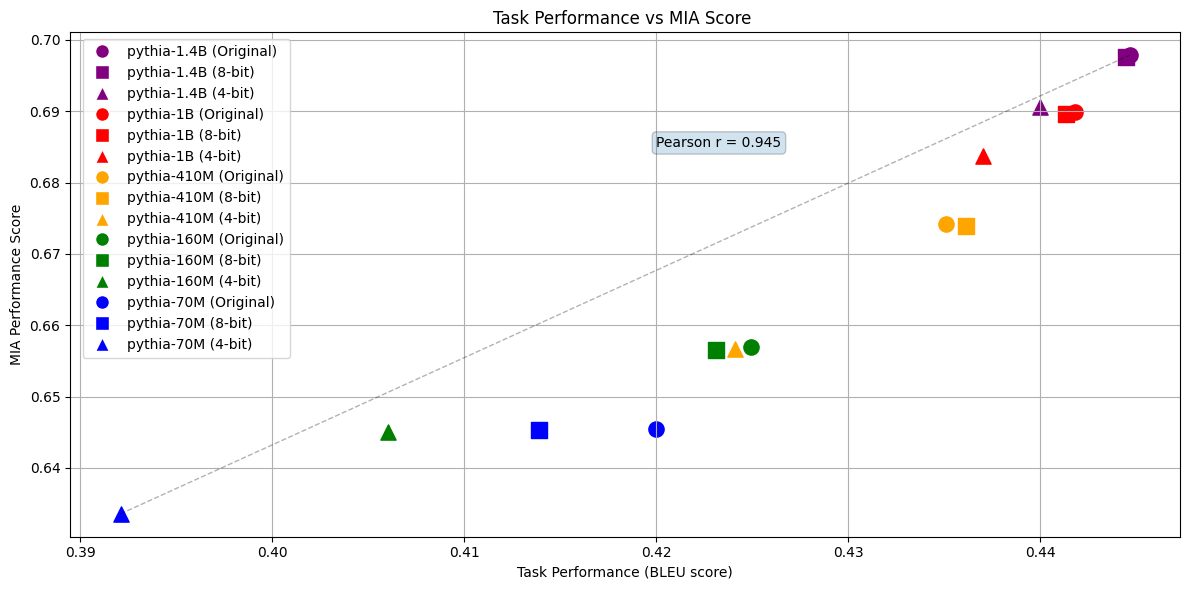

In [6]:
taskPerformance = "BLEU"
MIA_score = "ROC_AUC"
model_order = ['pythia-1.4B', 'pythia-1B','pythia-410M','pythia-160M', 'pythia-70M']
compression_order = ['Original', '8-bit', '4-bit']

plt.figure(figsize=(12, 6))
ax = plt.gca()

markers = {'Original': 'o', '8-bit': 's', '4-bit': '^'}
colors = {'pythia-70M': 'blue', 'pythia-160M': 'green',
          'pythia-410M': 'orange', 'pythia-1B': 'red',
          'pythia-1.4B': 'purple'}

# Create legend elements in desired order
legend_elements = []
for model in model_order:
    for compression in compression_order:
        subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
        if not subset.empty:
            scatter = plt.scatter(subset[taskPerformance], subset[MIA_score],
                                color=colors[model],
                                marker=markers[compression],
                                s=120)
            # Only add once per combination
            if len(legend_elements) < len(model_order) * len(compression_order):
                legend_elements.append(
                    plt.Line2D([0], [0], marker=markers[compression], color='w',
                              label=f'{model} ({compression})',
                              markerfacecolor=colors[model], markersize=10)
                )
# Add correlation line and annotation
plt.plot([df[taskPerformance].min(), df[taskPerformance].max()],
         [df[MIA_score].min(), df[MIA_score].max()],
         'k--', alpha=0.3, linewidth=1)
corr = df[taskPerformance].corr(df[MIA_score])
plt.annotate(f'Pearson r = {corr:.3f}', 
             xy=(0.42, 0.685), xycoords='data',
             fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))

plt.title('Task Performance vs MIA Score ')
plt.xlabel('Task Performance (BLEU score)')
plt.ylabel('MIA Performance Score')

# Sort legend elements by model first, then compression
sorted_elements = []
for model in model_order:
    for compression in compression_order:
        for element in legend_elements:
            if model in element.get_label() and compression in element.get_label():
                sorted_elements.append(element)
                break

plt.legend(handles=sorted_elements, bbox_to_anchor=(.005, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('./output/RQ3.1.png', dpi=300)
plt.show()

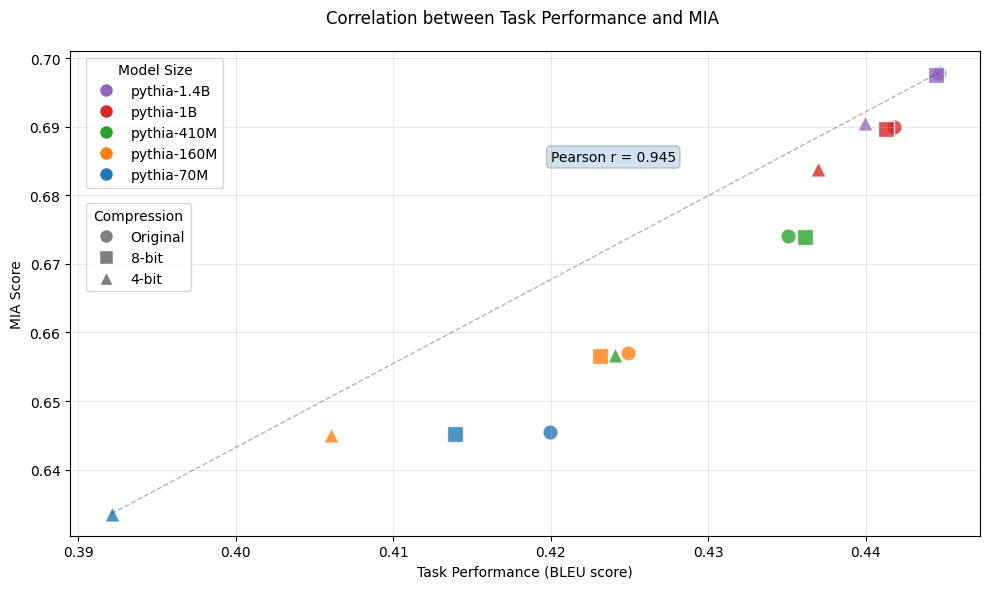

In [7]:
taskPerformance = "BLEU"
MIA_score = "ROC_AUC"
model_order = ['pythia-1.4B', 'pythia-1B','pythia-410M','pythia-160M', 'pythia-70M']

compression_order = ['Original', '8-bit', '4-bit']
markers = {'Original': 'o', '8-bit': 's', '4-bit': '^'}
colors = {'pythia-70M': '#1f77b4', 'pythia-160M': '#ff7f0e', 
          'pythia-410M': '#2ca02c', 'pythia-1B': '#d62728', 
          'pythia-1.4B': '#9467bd'}

# Create the optimized visualization
plt.figure(figsize=(10, 6))

# Plot each point with model-specific color and compression-specific marker
for model in model_order:
    for compression in compression_order:
        subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
        if not subset.empty:
            plt.scatter(subset[taskPerformance], subset[MIA_score],
                       c=colors[model],
                       marker=markers[compression],
                       s=120,
                       alpha=0.8,
                       edgecolors='w',
                       linewidths=1)

# Create custom legends
from matplotlib.lines import Line2D

# Model legend (color-coded)
model_legend_elements = [Line2D([0], [0], marker='o', color='w', label=model,
                         markerfacecolor=colors[model], markersize=10) 
                         for model in model_order]

# Compression legend (marker-coded)
compression_legend_elements = [Line2D([0], [0], marker=markers[comp], color='w', label=comp,
                               markerfacecolor='gray', markersize=10)
                               for comp in compression_order]

# Add legends
first_legend = plt.legend(handles=model_legend_elements, title='Model Size',
                         loc='upper left', bbox_to_anchor=(.01, 1))
plt.gca().add_artist(first_legend)
plt.legend(handles=compression_legend_elements, title='Compression',
           loc='upper left', bbox_to_anchor=(.01, 0.7))

# Add correlation line and annotation
plt.plot([df[taskPerformance].min(), df[taskPerformance].max()],
         [df[MIA_score].min(), df[MIA_score].max()],
         'k--', alpha=0.3, linewidth=1)
corr = df[taskPerformance].corr(df[MIA_score])
plt.annotate(f'Pearson r = {corr:.3f}', 
             xy=(0.42, 0.685), xycoords='data',
             fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))

# Labels and title
plt.title('Correlation between Task Performance and MIA ', pad=20)
plt.xlabel('Task Performance (BLEU score)')
plt.ylabel('MIA Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./output/RQ3.2.png', dpi=300)
plt.show()